# Simulation that makes sense

9600
 -----------------------------------------------------------------------
 ----------------------------  Results  --------------------------------
 MAX ENZYME ACTIVITY :  1.3392503104581577


<Figure size 700x500 with 0 Axes>

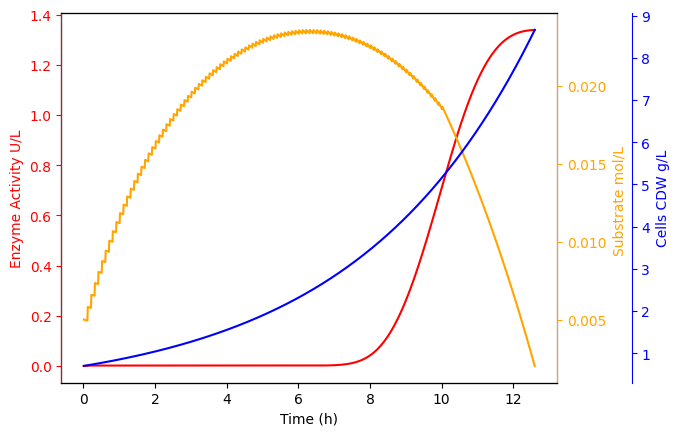

Initial substrate to cell ratio:  7142.857142857143


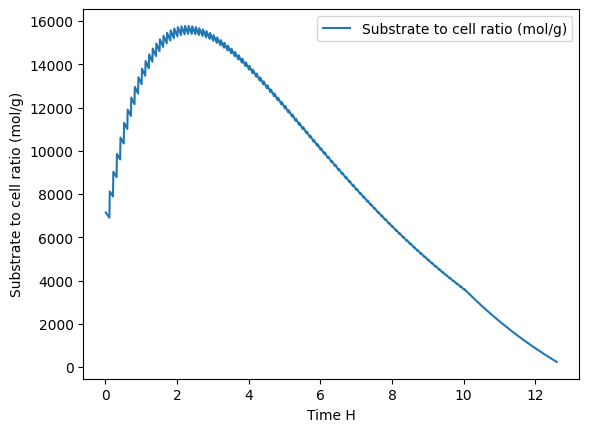

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import math
import pandas as pd
import random 
import config
from scipy.interpolate import CubicSpline
import utils

weibull_values = pd.read_csv('pdfcsv.csv')
xvalues = weibull_values['x']
y_values = weibull_values['pdf']

# Create a cubic spline interpolation model
cs = CubicSpline(xvalues, y_values)


# Initial conditions
X0 = config.X0  # CDW g/L 
S0 = config.S0 # mol/L
E0 = config.E0 # U/L 

# Process conditions
T = config.INIT_TEMPRATURE #'C 
T_opt = config.OPTIMUM_TEMPERATURE #'C
A = config.INIT_AGITATION # RPM

# model parameters
Ks = config.KS    # mol/L
Yxs =  config.YXS  # CDW g/mol
MuE_opt = config.MUE_OPT    # U/CDW g
mu_max = config.MU_MAX   # /h
del_t = config.DEL_T # hours ie. 36 seconds
t_end = config.T_END
total_sim_steps = int(t_end/del_t)
tvec = [del_t + i * del_t for i in range(total_sim_steps)]
ns = len(tvec)
print(ns)
kl = config.KL # mol/L
cell_death_timer = config.CELL_DEATH_TIMER
cell_death_time = config.CELL_DEATH_TIME

# Substrate addition calculations
tank_capacity = config.TANK_CAPACITY # L
substrate_in_tank_liters = config.SUBSTRATE_IN_TANK_LITERS # L
max_substrate_limit_liters = config.MAX_SUBSTRATE_LIMIT_LITERS # L
substrate_transfer_amount_liters = config.SUBSTRATE_TRANSFER_AMOUNT_LITERS # L 
media_transfer_gap =  config.MEDIA_TRANSFER_GAP # Hours this is after 10 steps ie. 6 minutes
media_transfer_step = int(media_transfer_gap/del_t)
substrate_concentration = S0
sub_in_tank_moles = S0 * substrate_in_tank_liters # mol

# external media tank configurations
ext_tank_substrate_conc = config.EXT_TANK_SUBSTRATE_CONC # mol/L
substrate_transfer_moles = substrate_transfer_amount_liters * ext_tank_substrate_conc # mol 

# X S E delE delX, muE
D = np.zeros((ns+1, 6))
D[0][0] = X0
D[0][1] = substrate_concentration
D[0][2] = E0

for i in range(ns):
    X = D[i][0]
    S = D[i][1]
    E = D[i][2]

    MuX = utils.cell_growth_rate(S)
    # new cells that are generated
    dXdt = utils.cells_produced(X, MuX)

    # SUbstrate consumption
    dSdt = utils.substrate_consumed(dXdt)

    # Find change in cells 
    delX = dXdt * del_t
    # Update cells
    D[i+1][0] = X + delX
    
    # Find change in substrate
    delS = dSdt * del_t

    # # Update substrate
    if substrate_in_tank_liters < max_substrate_limit_liters:
        if i%(media_transfer_step) == 0 and i != 0:
            substrate_action = 0.01
            if True:
                # get substrate concentraion for current timestep
                substrate_concentration = S
                sub_in_tank_moles = substrate_concentration * substrate_in_tank_liters
                # Add substrate and calculate new concentraion
                substrate_in_tank_liters = substrate_in_tank_liters + substrate_action # Liters of media
                sub_in_tank_moles = sub_in_tank_moles + ext_tank_substrate_conc * substrate_action  # grams
                substrate_concentration = sub_in_tank_moles/substrate_in_tank_liters # substrate grams/liter
                S = substrate_concentration

    # Check if substrate is less than or close to 0
    if S + delS < 0.000001:
        D[i+1][1] = 0
    else:
        D[i+1][1] = S + delS

    # Enzyme determination 
    sub_cell_ratio = (S/X) * 1e6

    weibull = utils.enzyme_production_rate(sub_cell_ratio, cs)
    MuE = MuE_opt * weibull

    if dXdt == 0:
        MuE = 0

    # new enzyme from fresh cells
    delE = MuE * X * del_t
    
    # Update enzyme variable
    D[i+1][2] = E + delE

    # terminate if tank capacity is full and cells start dying
    if substrate_in_tank_liters >= max_substrate_limit_liters and dXdt == 0:
        break
    
X = D[:,0][0:i]
S = D[:,1][0:i]
E = D[:,2][0:i]
MUE = D[:,5][0:i]
S_C_R = S/X
S_C_R = S_C_R * 1e6

max_enzyme = round(max(E),3)
sub_max = round(max(S),3)
max_cells = round(max(X),3)

'''
================================================================================================================================================
                                                    Plotting      
================================================================================================================================================
'''

print(" -----------------------------------------------------------------------")
print(" ----------------------------  Results  --------------------------------")
print(" MAX ENZYME ACTIVITY : ", max(D[:,2]))

plt.figure(figsize=(7,5))
fig, ax1 = plt.subplots()
#fig.suptitle(f"Max Cells: {max_cells} CDWg/L, Max Substrate: {sub_max} mol/L, Max Enzyme Activity: {max_enzyme} U/L" )
#fig.suptitle(f"Simulation: Fed Batch Mode")
ax1.plot(tvec[0:i] ,E ,color="red", label= "Enzyme Activity U/L")

ax2 = ax1.twinx()
ax2.plot(tvec[0:i], S, color="orange", label="Substrate mol/L")

ax3 = ax1.twinx()
ax3.plot(tvec[0:i] , X ,color="blue", label="Cells CDW g/L")
#ax3.spines['right'].set_position(('outward',60))
ax3.spines['right'].set_position(('axes',1.15))

ax1.set_ylabel("Enzyme Activity U/L", color="red")
ax1.set_xlabel("Time (h)")
ax2.set_ylabel("Substrate mol/L ", color="orange")
ax3.set_ylabel("Cells CDW g/L", color="blue")

ax1.tick_params(axis='y',colors="red")
ax2.tick_params(axis='y',colors="orange")
ax3.tick_params(axis='y',colors="blue")

ax2.spines['right'].set_color("orange")
ax3.spines['right'].set_color("blue")
ax3.spines['left'].set_color("red")
#fig.legend()
plt.show()

plt.plot(tvec[:len(S_C_R)], S_C_R, label="Substrate to cell ratio (mol/g)")
print("Initial substrate to cell ratio: ",S_C_R[0])
plt.xlabel("Time H")
plt.ylabel("Substrate to cell ratio (mol/g)")
plt.legend()

# Ramp function

9600


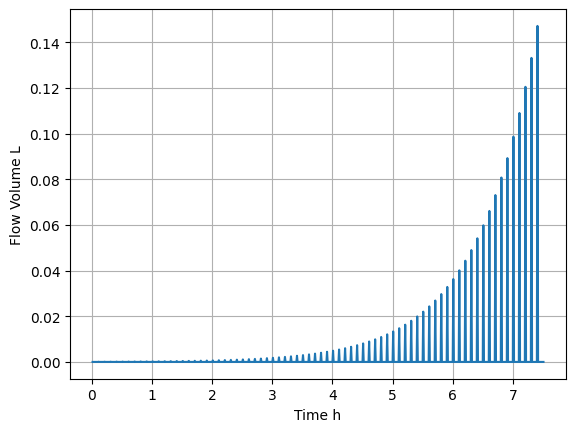

In [ ]:
import math
import matplotlib.pyplot as plt

# Parameters
initial_volume = 9e-5       # Starting population
ramp_rate = 0.1             # Growth rate (e.g., 20% per iteration)

# Initialize variables
flow_volume = initial_volume
volumes = []
time_vector = tvec
# Simulate exponential growth
for i in range(ns):
    if i%(media_transfer_step) == 0 and i != 0:
        if sum(volumes) <= 1.5:
            flow_volume = flow_volume * math.exp(ramp_rate)  # Increase population exponentially
            volumes.append(flow_volume)
        else:
            volumes.append(0)
            break
    else:
        volumes.append(0)
print(len(time_vector))

plt.plot(time_vector[:len(volumes)], volumes)
plt.xlabel("Time h")
plt.ylabel("Flow Volume L")
plt.grid(True)







# Exponential equation implemented on simulation

 -----------------------------------------------------------------------
 ----------------------------  Results  --------------------------------
 MAX ENZYME ACTIVITY :  4.205516076821631


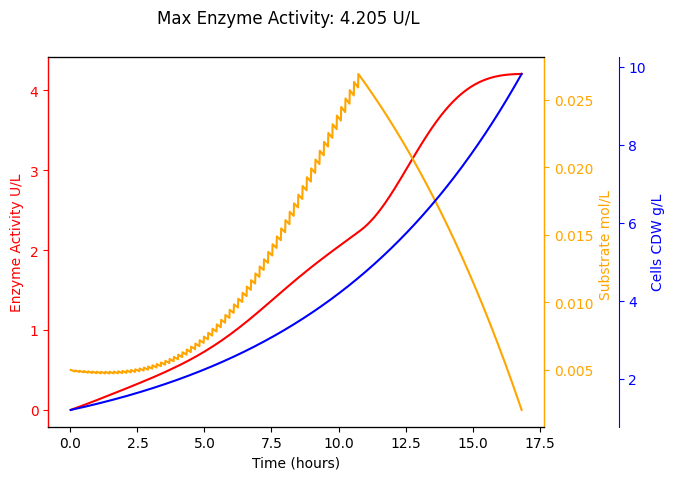

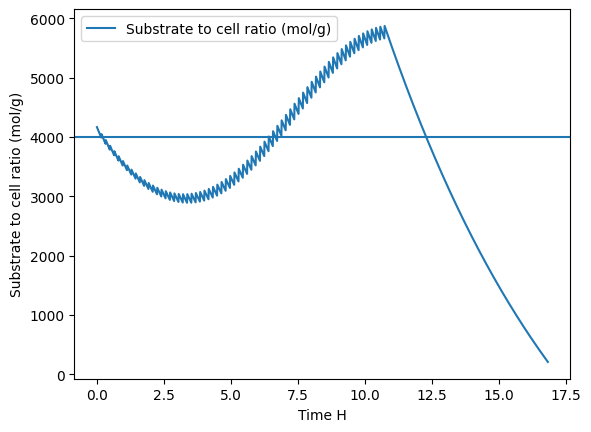

: 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math
import pandas as pd
import random 
import config
from scipy.interpolate import CubicSpline
import utils

weibull_values = pd.read_csv('pdfcsv.csv')
xvalues = weibull_values['x']
y_values = weibull_values['pdf']

# Create a cubic spline interpolation model
cs = CubicSpline(xvalues, y_values)

initial_volume = 0.0008940234401919025
flow_volume = initial_volume
ramp_rate = 0.06416817479783203
transfer_interval = 0.1668597235239694

# Initial conditions
X0 = 1.2  # CDW g/L 
S0 = config.S0 # mol/L
E0 = config.E0 # U/L 

# Process conditions
T = config.INIT_TEMPRATURE #'C 
T_opt = config.OPTIMUM_TEMPERATURE #'C
A = config.INIT_AGITATION # RPM

# model parameters
Ks = config.KS    # mol/L
Yxs =  config.YXS  # CDW g/mol
MuE_opt = config.MUE_OPT    # U/CDW g
mu_max = 0.125   # /h
del_t = config.DEL_T # hours ie. 36 seconds
t_end = config.T_END
total_sim_steps = int(t_end/del_t)
tvec = [del_t + i * del_t for i in range(total_sim_steps)]
ns = len(tvec)
kl = config.KL # mol/L
cell_death_timer = config.CELL_DEATH_TIMER
cell_death_time = config.CELL_DEATH_TIME

# Substrate addition calculations
tank_capacity = config.TANK_CAPACITY # L
substrate_in_tank_liters = config.SUBSTRATE_IN_TANK_LITERS # L
max_substrate_limit_liters = config.MAX_SUBSTRATE_LIMIT_LITERS # L
substrate_transfer_amount_liters = config.SUBSTRATE_TRANSFER_AMOUNT_LITERS # L 
media_transfer_gap =  transfer_interval # Hours this is after 10 steps ie. 6 minutes
media_transfer_step = int(media_transfer_gap/del_t)
substrate_concentration = S0
sub_in_tank_moles = S0 * substrate_in_tank_liters # mol

# external media tank configurations
ext_tank_substrate_conc = config.EXT_TANK_SUBSTRATE_CONC # mol/L
substrate_transfer_moles = substrate_transfer_amount_liters * ext_tank_substrate_conc # mol 

# X S E delE delX, muE
D = np.zeros((ns+1, 6))
D[0][0] = X0
D[0][1] = substrate_concentration
D[0][2] = E0

for i in range(ns):
    X = D[i][0]
    S = D[i][1]
    E = D[i][2]

    MuX = utils.cell_growth_rate_test(S,mu_max)
    # new cells that are generated
    dXdt = utils.cells_produced(X, MuX)

    # SUbstrate consumption
    dSdt = utils.substrate_consumed(dXdt)

    # Find change in cells 
    delX = dXdt * del_t
    # Update cells
    D[i+1][0] = X + delX
    
    # Find change in substrate
    delS = dSdt * del_t

    # # Update substrate
    if substrate_in_tank_liters < max_substrate_limit_liters:
        if i%(media_transfer_step) == 0 and i != 0:
            flow_volume *= math.exp(ramp_rate)
            substrate_action = flow_volume
            if True:
                # get substrate concentraion for current timestep
                substrate_concentration = S
                sub_in_tank_moles = substrate_concentration * substrate_in_tank_liters
                # Add substrate and calculate new concentraion
                substrate_in_tank_liters = substrate_in_tank_liters + substrate_action # Liters of media
                sub_in_tank_moles = sub_in_tank_moles + ext_tank_substrate_conc * substrate_action  # grams
                substrate_concentration = sub_in_tank_moles/substrate_in_tank_liters # substrate grams/liter
                S = substrate_concentration

    # Check if substrate is less than or close to 0
    if S + delS < 0.000001:
        D[i+1][1] = 0
    else:
        D[i+1][1] = S + delS

    # Enzyme determination 
    sub_cell_ratio = (S/X) * 1e6

    weibull = utils.enzyme_production_rate(sub_cell_ratio, cs)
    MuE = MuE_opt * weibull

    if dXdt == 0:
        MuE = 0

    # new enzyme from fresh cells
    delE = MuE * X * del_t
    
    # Update enzyme variable
    D[i+1][2] = E + delE

    # terminate if tank capacity is full and cells start dying
    if substrate_in_tank_liters >= max_substrate_limit_liters and dXdt == 0:
        break
    
X = D[:,0][0:i]
S = D[:,1][0:i]
E = D[:,2][0:i]
MUE = D[:,5][0:i]
S_C_R = S/X
S_C_R = S_C_R * 1e6

max_enzyme = round(max(E),3)
sub_max = round(max(S),3)
max_cells = round(max(X),3)

'''
================================================================================================================================================
                                                    Plotting      
================================================================================================================================================
'''

print(" -----------------------------------------------------------------------")
print(" ----------------------------  Results  --------------------------------")
print(" MAX ENZYME ACTIVITY : ", max(D[:,2]))

fig, ax1 = plt.subplots()
fig.suptitle(f"Max Enzyme Activity: {max_enzyme} U/L" )
#fig.suptitle(f"Simulation: Fed Batch Mode")
ax1.plot(tvec[0:i] ,E ,color="red", label= "Enzyme Activity U/L")

ax2 = ax1.twinx()
ax2.plot(tvec[0:i], S, color="orange", label="Substrate mol/L")

ax3 = ax1.twinx()
ax3.plot(tvec[0:i] , X ,color="blue", label="Cells CDW g/L")
#ax3.spines['right'].set_position(('outward',60))
ax3.spines['right'].set_position(('axes',1.15))

ax1.set_ylabel("Enzyme Activity U/L", color="red")
ax1.set_xlabel("Time (hours)")
ax2.set_ylabel("Substrate mol/L ", color="orange")
ax3.set_ylabel("Cells CDW g/L", color="blue")

ax1.tick_params(axis='y',colors="red")
ax2.tick_params(axis='y',colors="orange")
ax3.tick_params(axis='y',colors="blue")

ax2.spines['right'].set_color("orange")
ax3.spines['right'].set_color("blue")
ax3.spines['left'].set_color("red")
#fig.legend()
plt.show()

plt.plot(tvec[:len(S_C_R)], S_C_R, label="Substrate to cell ratio (mol/g)")
plt.axhline(y=config.OPT_SUB_CELL_RATIO*1e6)
plt.xlabel("Time H")
plt.ylabel("Substrate to cell ratio (mol/g)")
plt.legend()

# New exponential formula

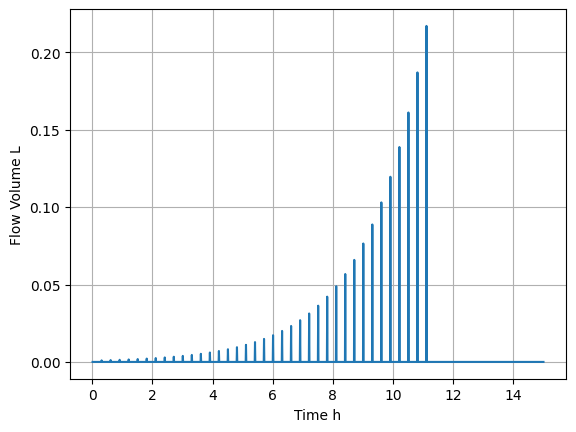

In [121]:
import math
import matplotlib.pyplot as plt

# Parameters
initial_volume = 0.0008758965052056445       # Starting population
ramp_rate = 0.14898739303677924            # Growth rate 
del_t = 0.01
media_transfer_gap = 0.3
media_transfer_step = media_transfer_gap/del_t
# Initialize variables
flow_volume = initial_volume
volumes = []
tvec = [del_t + i * del_t for i in range(int(15/del_t))]

# Simulate exponential growth
for i in range(len(tvec)):
    if i%(media_transfer_step) == 0 and i != 0:
        if sum(volumes) <= 1.5:
            flow_volume *= math.exp(ramp_rate)  # Increase population exponentially
            volumes.append(flow_volume)
        else:
            volumes.append(0)
    else:
        volumes.append(0)


plt.plot(tvec, volumes)
plt.xlabel("Time h")
plt.ylabel("Flow Volume L")
plt.grid(True)

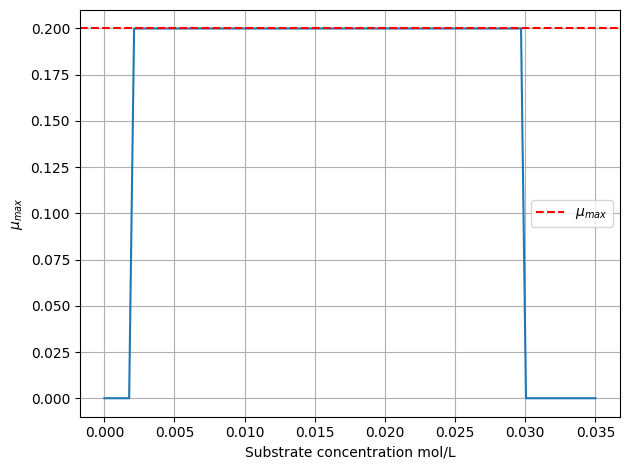

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import utils
import config

s_conc = np.linspace(0, 0.035, 100)
rates = []

for S in s_conc:
    rates.append(utils.cell_growth_rate(S))

plt.plot(s_conc, rates)
plt.xlabel("Substrate concentration mol/L")
plt.ylabel(r"$\mu_{max}$")
plt.grid(True)
plt.axhline(y=config.MU_MAX, color='red', label=r"$\mu_{max}$", linestyle='--')
plt.legend()

# Remove white space around the plot
plt.tight_layout()

plt.show()


Text(0, 0.5, 'cell growth rate')

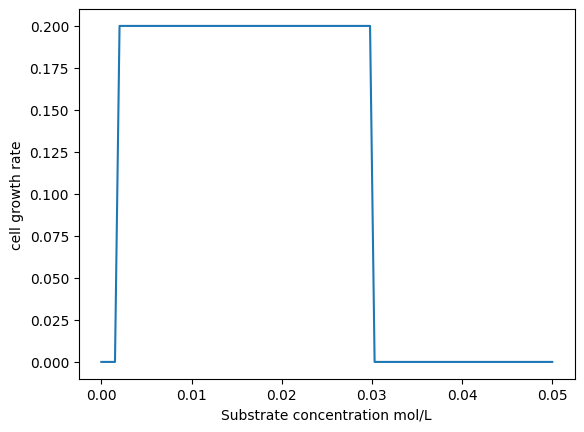

In [123]:
import numpy as np
import matplotlib.pyplot as plt
import config


s_conc = np.linspace(0 , 0.05 ,100)
rates = []

for S in s_conc:
    if S < 0.002 or S > 0.030:
        rate = 0
    else:
        rate = config.MU_MAX
    
    rates.append(rate)


plt.plot(s_conc, rates)
plt.xlabel("Substrate concentration mol/L")
plt.ylabel("cell growth rate")

Text(0, 0.5, 'Reward')

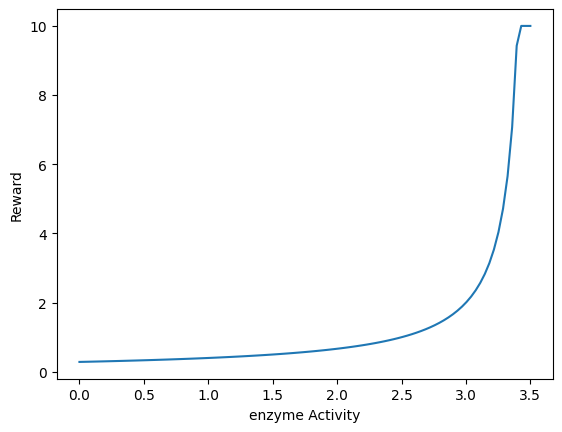

In [124]:
import numpy as np
import matplotlib.pylab as plt

def reward_function(current_enzyme_activity, target_activity=3.5):
    """
    Reward function for enzyme activity optimization.

    Args:
    - current_enzyme_activity (float): The current enzyme activity (U/L).
    - target_activity (float, optional): The target enzyme activity (U/L). Default is 4.0.

    Returns:
    - float: The calculated reward.
    """
    # Calculate the absolute distance to the target
    distance = abs(target_activity - current_enzyme_activity)
    
    # Reward inversely proportional to the distance
    # Add a small epsilon to avoid division by zero when distance is very small
    epsilon = 1e-5
    reward = 1 / (distance + epsilon)
    
    # Optionally scale or normalize the reward to avoid extreme values
    reward = min(reward, 10)  # Cap the reward at 100 for stability
    
    return reward


activities = np.linspace(0, 3.5, 100)
rewards = []

for i in activities:
    rewards.append(reward_function(i))

plt.plot(activities, rewards)
plt.xlabel("enzyme Activity")
plt.ylabel("Reward")


Text(0, 0.5, 'reward')

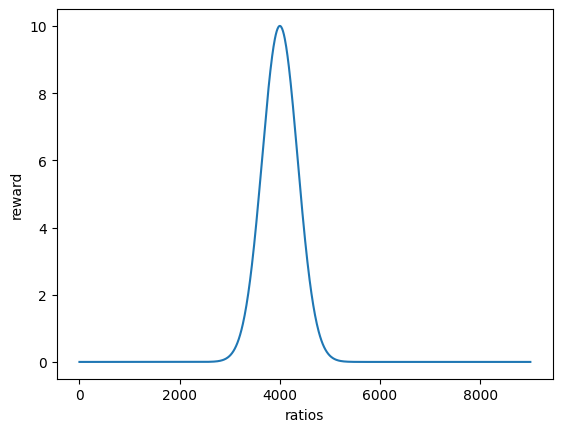

In [125]:
import numpy as np
import config
import numpy as np
import matplotlib.pyplot as plt

def scr_reward(ratio):
    """
    Calculate the maximum growth rate using the given formula.

    Args:
    - mu_opt (float): Optimal growth rate.
    - T (float): Current temperature (or variable of interest).
    - T_opt (float): Optimal temperature (or variable of interest).
    - r (float): Spread or tolerance parameter.

    Returns:
    - float: Maximum growth rate (mu_max).
    """
    reward = 10 * np.exp(-((ratio/1e6 - config.OPT_SUB_CELL_RATIO) ** 2) / (0.0005 ** 2))
    return reward


ratios = np.linspace(0, 9000, 1000)
rewards = []
for i in ratios:
    reward = scr_reward(i)
    rewards.append(reward)

plt.plot(ratios, rewards)
plt.xlabel("ratios")
plt.ylabel("reward")


